# Smarter Calling — Predictive Targeting for Bank Telemarketing
**Course:** MGMT 52610 — Data & AI-Driven Marketing  
**Dataset:** Portuguese Bank Telemarketing Campaign (targeted-telemarketing.csv)  
**Topics:** Logistic regression, profit-based decision rules, classification metrics, targeted vs. mass marketing  
**Author:** Sana Majeed

---
## 1. Dataset Overview

The dataset contains records from a Portuguese bank's direct telemarketing campaign aimed at selling **term deposit subscriptions**. Each row represents one customer contact attempt.

**Key variables:**

| Column | Type | Description |
|---|---|---|
| `age` | numeric | Customer age |
| `job` | categorical | Type of employment |
| `marital` | categorical | Marital status |
| `education` | categorical | Education level |
| `default` | binary | Has credit in default? |
| `housing` | binary | Has housing loan? |
| `loan` | binary | Has personal loan? |
| `contact` | categorical | Contact communication type |
| `month` | categorical | Month of last contact |
| `day_of_week` | categorical | Day of last contact |
| `pdays` | numeric | Days since last contact from previous campaign |
| `previous` | numeric | Number of contacts before this campaign |
| `poutcome` | categorical | Outcome of previous campaign |
| `emp.var.rate` | numeric | Employment variation rate (economic indicator) |
| `cons.price.idx` | numeric | Consumer price index (economic indicator) |
| `cons.conf.idx` | numeric | Consumer confidence index |
| `euribor3m` | numeric | Euribor 3-month rate |
| `nr.employed` | numeric | Number of employees (economic indicator) |
| `y` | binary | **Target: did the customer subscribe?** (yes/no) |

**Economics of the campaign:**
- Revenue per successful subscription: **200 USD**
- Cost per call made: **20 USD**

---
## 2. Assumptions

1. **Fixed revenue and cost:** Every subscription earns $200; every call costs $20 regardless of duration or outcome.
2. **Binary outcome:** A customer either subscribes or does not — no partial conversions.
3. **Independence of calls:** Each customer contact is treated as independent.
4. **Logistic regression is appropriate:** We assume a log-odds linear relationship between customer features and subscription probability.
5. **Advertising is exogenous:** The decision of who to call is not itself driven by predicted outcomes in the original dataset.
6. **Cleaned sample is representative:** After removing illiterate, defaulted, and unknown-status customers, the remaining sample generalises to the target population.
7. **50/50 train-test split:** Random split with fixed seed for reproducibility.

---
## 3. Methodology

```
Raw Data → Data Cleaning → Feature Engineering → Train/Test Split
    → Profit-Based Cutoff Derivation → Logistic Regression Model
    → Classifier Evaluation (Sensitivity, Specificity, Precision, Recall, F1)
    → Targeted vs. Mass Marketing Profit Comparison
```

**Step 1 — Profit-based cutoff first:** Before modelling, we derive the optimal probability threshold mathematically from the cost/revenue structure. This ensures the decision rule is grounded in business economics, not arbitrary thresholds like 0.5.

**Step 2 — Data cleaning:** Remove invalid/ambiguous records that would introduce noise.

**Step 3 — Feature encoding:** One-hot encode categorical variables for logistic regression compatibility.

**Step 4 — Logistic regression:** Estimate the probability of subscription for each customer. Use statsmodels for interpretable coefficients and p-values.

**Step 5 — Model evaluation:** Assess the classifier using sensitivity, specificity, precision, recall, F1, and confusion matrices on both training and test sets.

**Step 6 — Profit comparison:** Quantify the business value of targeted vs. mass calling.

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'serif'
NAVY  = '#1B2A4A'
GOLD  = '#C9A84C'
CREAM = '#F5F0E8'
MUTED = '#8A94A6'

---
## 4. Data Loading & Cleaning

In [2]:
# ── Load data ─────────────────────────────────────────────────────────────────
df_raw = pd.read_csv('targeted-telemarketing.csv', sep=';')
print(f'Raw dataset: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'Subscription rate (raw): {(df_raw["y"]=="yes").mean():.1%}')
df_raw.head(3)

Raw dataset: 41,188 rows × 21 columns
Subscription rate (raw): 11.3%


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
# ── Data Cleaning ─────────────────────────────────────────────────────────────
df = df_raw.copy()

df = df[df['education'] != 'illiterate']   # Too few, unreliable
df = df[df['default']   != 'yes']          # Credit defaulters excluded
df = df[df['marital']   != 'unknown']      # Remove ambiguous records
df = df[df['housing']   != 'unknown']
df = df[df['loan']      != 'unknown']
df = df[df['y'].notna()]                   # No missing targets
df = df[df['previous']  >  0]              # Must have prior contact history

df = df.reset_index(drop=True)
print(f'Cleaned dataset: {df.shape[0]:,} rows (removed {df_raw.shape[0]-df.shape[0]:,} records)')
print(f'Subscription rate (cleaned): {(df["y"]=="yes").mean():.1%}')

Cleaned dataset: 5,465 rows (removed 35,723 records)
Subscription rate (cleaned): 26.5%


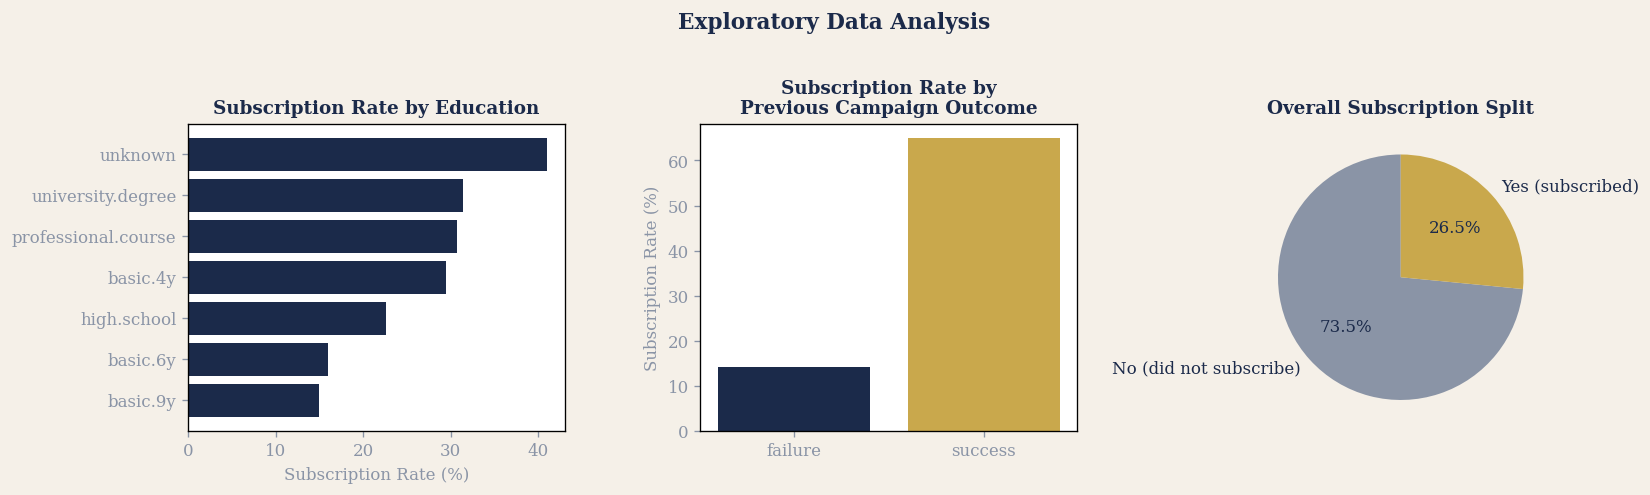

In [4]:
# ── EDA: Subscription rate by key segments ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.patch.set_facecolor(CREAM)

for ax in axes:
    ax.set_facecolor('white')

# By education
edu_rate = df.groupby('education')['y'].apply(lambda x: (x=='yes').mean()).sort_values()
axes[0].barh(edu_rate.index, edu_rate.values * 100, color=NAVY)
axes[0].set_title('Subscription Rate by Education', fontsize=11, color=NAVY, fontweight='bold')
axes[0].set_xlabel('Subscription Rate (%)', color=MUTED)
axes[0].tick_params(colors=MUTED)

# By poutcome
po_rate = df.groupby('poutcome')['y'].apply(lambda x: (x=='yes').mean()).sort_values()
colors = [GOLD if v == po_rate.max() else NAVY for v in po_rate.values]
axes[1].bar(po_rate.index, po_rate.values * 100, color=colors)
axes[1].set_title('Subscription Rate by\nPrevious Campaign Outcome', fontsize=11, color=NAVY, fontweight='bold')
axes[1].set_ylabel('Subscription Rate (%)', color=MUTED)
axes[1].tick_params(colors=MUTED)

# Target distribution
counts = df['y'].value_counts()
axes[2].pie(counts.values, labels=['No (did not subscribe)', 'Yes (subscribed)'],
            colors=[MUTED, GOLD], autopct='%1.1f%%', startangle=90,
            textprops={'color': NAVY})
axes[2].set_title('Overall Subscription Split', fontsize=11, color=NAVY, fontweight='bold')

plt.suptitle('Exploratory Data Analysis', fontsize=13, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Profit-Based Decision Rule (Cutoff Derivation)

Before building the model, we establish the optimal calling threshold mathematically.

Let **p** = predicted probability a customer subscribes.

$$\text{Expected Profit (call)} = 200p - 20$$
$$\text{Expected Profit (no call)} = 0$$

Calling is profitable when:
$$200p - 20 > 0 \implies p > \frac{20}{200} = 0.10$$

**Optimal cutoff = 10%.** Call any customer whose predicted subscription probability exceeds 10%.

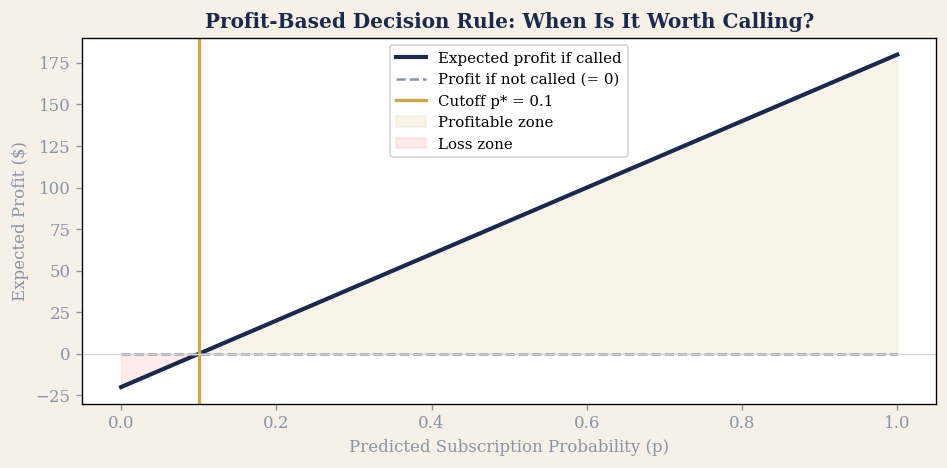

Optimal cutoff probability: p* = 0.1 (10%)


In [5]:
# ── Visualise the profit rule ─────────────────────────────────────────────────
p_vals = np.linspace(0, 1, 200)
profit_call   = 200 * p_vals - 20
profit_nocall = np.zeros_like(p_vals)
CUTOFF = 0.10

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor(CREAM)
ax.set_facecolor('white')

ax.plot(p_vals, profit_call,   color=NAVY, linewidth=2.5, label='Expected profit if called')
ax.plot(p_vals, profit_nocall, color=MUTED, linewidth=1.5, linestyle='--', label='Profit if not called (= 0)')
ax.axvline(x=CUTOFF, color=GOLD, linewidth=2, linestyle='-', label=f'Cutoff p* = {CUTOFF}')
ax.axhline(y=0, color='lightgrey', linewidth=0.8)

ax.fill_between(p_vals, profit_call, 0,
                where=(p_vals >= CUTOFF), alpha=0.12, color=GOLD, label='Profitable zone')
ax.fill_between(p_vals, profit_call, 0,
                where=(p_vals < CUTOFF),  alpha=0.08, color='red',  label='Loss zone')

ax.set_xlabel('Predicted Subscription Probability (p)', color=MUTED)
ax.set_ylabel('Expected Profit ($)', color=MUTED)
ax.set_title('Profit-Based Decision Rule: When Is It Worth Calling?',
             fontsize=12, fontweight='bold', color=NAVY)
ax.legend(fontsize=9)
ax.tick_params(colors=MUTED)
plt.tight_layout()
plt.show()

print(f'Optimal cutoff probability: p* = {CUTOFF} ({CUTOFF:.0%})')

---
## 6. Feature Engineering & Train/Test Split

In [6]:
# ── Feature encoding ──────────────────────────────────────────────────────────
FEATURES = [
    'age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
    'contact', 'month', 'day_of_week', 'pdays', 'previous', 'poutcome',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'
]

X = pd.get_dummies(df[FEATURES], drop_first=True).astype(float)
y = (df['y'] == 'yes').astype(int)  # 1 = subscribed, 0 = did not

# 50/50 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=1
)

print(f'Training set:  {X_train.shape[0]:,} customers  |  {y_train.sum():,} subscribers ({y_train.mean():.1%})')
print(f'Test set:      {X_test.shape[0]:,} customers  |  {y_test.sum():,} subscribers ({y_test.mean():.1%})')
print(f'Features used: {X_train.shape[1]}')

Training set:  2,732 customers  |  727 subscribers (26.6%)
Test set:      2,733 customers  |  723 subscribers (26.5%)
Features used: 45


---
## 7. Baseline: Net Profit from Calling Everyone

In [7]:
# ── Baseline — call all customers ─────────────────────────────────────────────
REVENUE_PER_SUB = 200
COST_PER_CALL   = 20

n_test       = len(y_test)
subs_all     = y_test.sum()
revenue_all  = subs_all * REVENUE_PER_SUB
cost_all     = n_test   * COST_PER_CALL
profit_all   = revenue_all - cost_all

print('── Baseline: Call Everyone ──────────────────')
print(f'  Customers called:    {n_test:,}')
print(f'  Actual subscribers:  {subs_all:,}')
print(f'  Revenue:             ${revenue_all:,.0f}')
print(f'  Calling cost:        ${cost_all:,.0f}')
print(f'  Net profit:          ${profit_all:,.0f}')

── Baseline: Call Everyone ──────────────────
  Customers called:    2,733
  Actual subscribers:  723
  Revenue:             $144,600
  Calling cost:        $54,660
  Net profit:          $89,940


---
## 8. Logistic Regression Model

In [8]:
# ── Fit logistic regression (statsmodels for p-values) ────────────────────────
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

logit_model = sm.Logit(y_train, X_train_sm)
result      = logit_model.fit(disp=False)

# Significant variables at 5%, sorted by effect size
summary_tbl = result.summary2().tables[1]
sig = summary_tbl[summary_tbl['P>|z|'] < 0.05].copy()
sig_sorted = sig.reindex(sig['Coef.'].abs().sort_values(ascending=False).index)

print('Top 10 most influential variables (significant at 5%):')
print(sig_sorted[['Coef.', 'Std.Err.', 'z', 'P>|z|']].head(10).round(4))

Top 10 most influential variables (significant at 5%):
                    Coef.  Std.Err.       z   P>|z|
cons.price.idx     2.8574    1.3522  2.1132  0.0346
emp.var.rate      -1.2999    0.4387 -2.9633  0.0030
poutcome_success   0.6649    0.2756  2.4130  0.0158
contact_telephone -0.5776    0.2167 -2.6649  0.0077
default_unknown   -0.5190    0.2483 -2.0900  0.0366
day_of_week_mon   -0.3976    0.1841 -2.1596  0.0308
cons.conf.idx      0.0765    0.0343  2.2299  0.0258
age                0.0149    0.0065  2.2924  0.0219
pdays             -0.0013    0.0003 -4.6314  0.0000


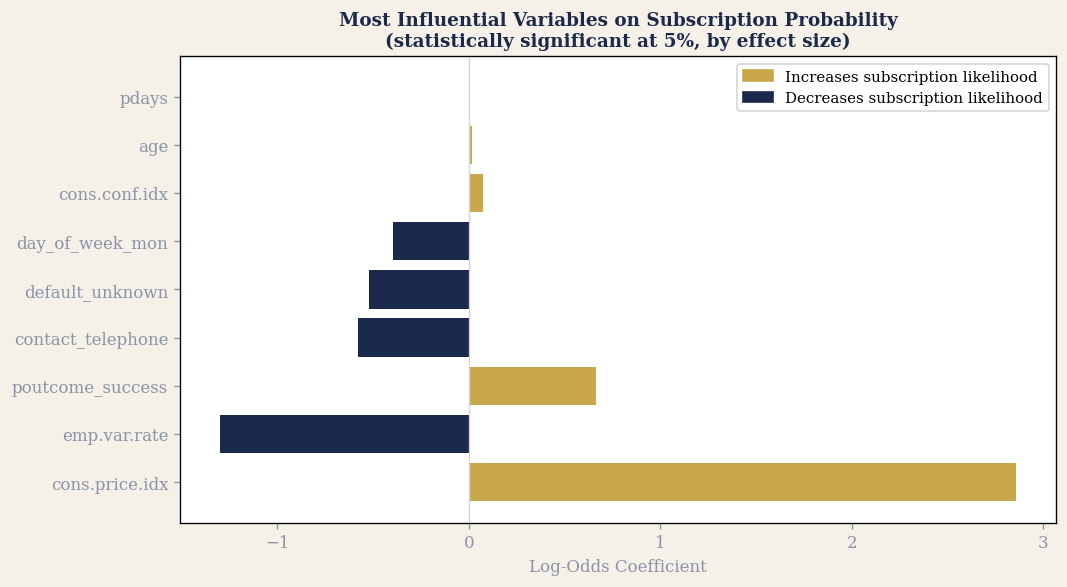

In [9]:
# ── Visualise top coefficients ────────────────────────────────────────────────
top_coefs = sig_sorted['Coef.'].head(12)

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(CREAM)
ax.set_facecolor('white')

colors = [GOLD if v > 0 else NAVY for v in top_coefs.values]
bars = ax.barh(top_coefs.index, top_coefs.values, color=colors)
ax.axvline(0, color='lightgrey', linewidth=0.8)
ax.set_title('Most Influential Variables on Subscription Probability\n(statistically significant at 5%, by effect size)',
             fontsize=11, fontweight='bold', color=NAVY)
ax.set_xlabel('Log-Odds Coefficient', color=MUTED)
ax.tick_params(colors=MUTED)

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=GOLD, label='Increases subscription likelihood'),
    Patch(color=NAVY, label='Decreases subscription likelihood')
], fontsize=9)

plt.tight_layout()
plt.show()

---
## 9. Model Evaluation — Classification Metrics

In [10]:
# ── Predict probabilities and apply cutoff ────────────────────────────────────
train_prob = result.predict(X_train_sm)
test_prob  = result.predict(X_test_sm)

train_pred = (train_prob >= CUTOFF).astype(int)
test_pred  = (test_prob  >= CUTOFF).astype(int)

# ── Confusion matrix function ─────────────────────────────────────────────────
def evaluate(y_true, y_pred, label=''):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sens      = tp / (tp + fn)  # Recall / Sensitivity
    spec      = tn / (tn + fp)  # Specificity
    precision = tp / (tp + fp)  # Precision
    f1        = 2 * precision * sens / (precision + sens)
    print(f'── {label} ──────────────────────────────')
    print(f'  True Positives (called, subscribed):       {tp:,}')
    print(f'  True Negatives (not called, correct):      {tn:,}')
    print(f'  False Positives (called, did not sub):     {fp:,}')
    print(f'  False Negatives (not called, would sub):   {fn:,}')
    print(f'  Sensitivity / Recall:  {sens:.3f}  ({sens:.1%})')
    print(f'  Specificity:           {spec:.3f}  ({spec:.1%})')
    print(f'  Precision:             {precision:.3f}  ({precision:.1%})')
    print(f'  F1 Score:              {f1:.3f}')
    print()
    return tn, fp, fn, tp, sens, spec, precision, f1

tn_tr, fp_tr, fn_tr, tp_tr, sens_tr, spec_tr, prec_tr, f1_tr = evaluate(y_train, train_pred, 'TRAINING SET')
tn_te, fp_te, fn_te, tp_te, sens_te, spec_te, prec_te, f1_te = evaluate(y_test,  test_pred,  'TEST SET')

── TRAINING SET ──────────────────────────────
  True Positives (called, subscribed):       666
  True Negatives (not called, correct):      1,177
  False Positives (called, did not sub):     828
  False Negatives (not called, would sub):   61
  Sensitivity / Recall:  0.916  (91.6%)
  Specificity:           0.587  (58.7%)
  Precision:             0.446  (44.6%)
  F1 Score:              0.600

── TEST SET ──────────────────────────────
  True Positives (called, subscribed):       651
  True Negatives (not called, correct):      1,138
  False Positives (called, did not sub):     872
  False Negatives (not called, would sub):   72
  Sensitivity / Recall:  0.900  (90.0%)
  Specificity:           0.566  (56.6%)
  Precision:             0.427  (42.7%)
  F1 Score:              0.580



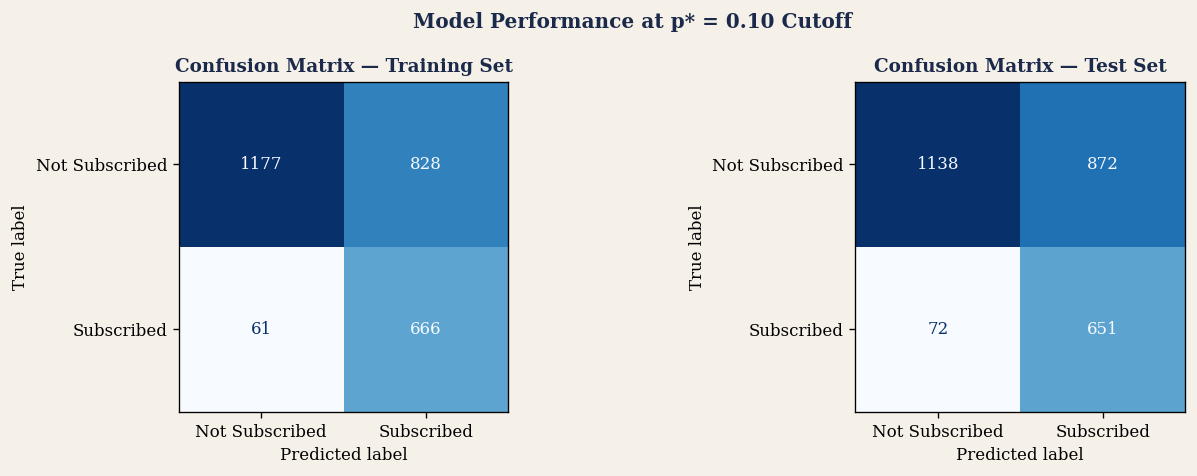

In [11]:
# ── Confusion matrices (visual) ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor(CREAM)

for ax, y_true, y_pred, title in [
    (axes[0], y_train, train_pred, 'Confusion Matrix — Training Set'),
    (axes[1], y_test,  test_pred,  'Confusion Matrix — Test Set')
]:
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Subscribed', 'Subscribed'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=11, fontweight='bold', color=NAVY)
    ax.set_facecolor('white')

plt.suptitle('Model Performance at p* = 0.10 Cutoff', fontsize=12, fontweight='bold', color=NAVY)
plt.tight_layout()
plt.show()

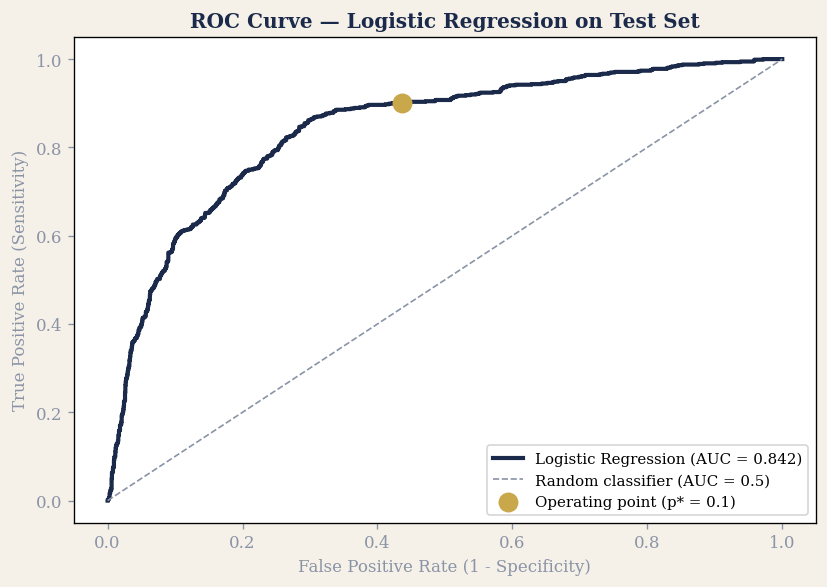

AUC Score: 0.8420


In [12]:
# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test, test_prob)
auc = roc_auc_score(y_test, test_prob)

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor(CREAM)
ax.set_facecolor('white')

ax.plot(fpr, tpr, color=NAVY, linewidth=2.5, label=f'Logistic Regression (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], color=MUTED, linestyle='--', linewidth=1, label='Random classifier (AUC = 0.5)')

# Mark the operating point at p* = 0.10
idx = np.argmin(np.abs(thresholds - CUTOFF))
ax.scatter(fpr[idx], tpr[idx], color=GOLD, s=120, zorder=5,
           label=f'Operating point (p* = {CUTOFF})')

ax.set_xlabel('False Positive Rate (1 - Specificity)', color=MUTED)
ax.set_ylabel('True Positive Rate (Sensitivity)', color=MUTED)
ax.set_title('ROC Curve — Logistic Regression on Test Set',
             fontsize=12, fontweight='bold', color=NAVY)
ax.legend(fontsize=9)
ax.tick_params(colors=MUTED)
plt.tight_layout()
plt.show()

print(f'AUC Score: {auc:.4f}')

---
## 10. Targeted vs. Mass Marketing — Profit Comparison

In [13]:
# ── Targeted strategy profit ───────────────────────────────────────────────────
n_targeted      = int(test_pred.sum())
subs_targeted   = tp_te
revenue_target  = subs_targeted * REVENUE_PER_SUB
cost_target     = n_targeted    * COST_PER_CALL
profit_targeted = revenue_target - cost_target

print('── Targeted Strategy ────────────────────────')
print(f'  Customers called:    {n_targeted:,}  (of {n_test:,} total, {n_targeted/n_test:.0%})')
print(f'  Actual subscribers:  {subs_targeted:,}')
print(f'  Revenue:             ${revenue_target:,.0f}')
print(f'  Calling cost:        ${cost_target:,.0f}')
print(f'  Net profit:          ${profit_targeted:,.0f}')
print()
print(f'  Profit improvement over baseline: +${profit_targeted - profit_all:,.0f} ({(profit_targeted-profit_all)/profit_all:.1%})')
print(f'  Call volume reduction:            -{n_test - n_targeted:,} fewer calls ({(n_test-n_targeted)/n_test:.0%} reduction)')

── Targeted Strategy ────────────────────────
  Customers called:    1,523  (of 2,733 total, 56%)
  Actual subscribers:  651
  Revenue:             $130,200
  Calling cost:        $30,460
  Net profit:          $99,740

  Profit improvement over baseline: +$9,800 (10.9%)
  Call volume reduction:            -1,210 fewer calls (44% reduction)


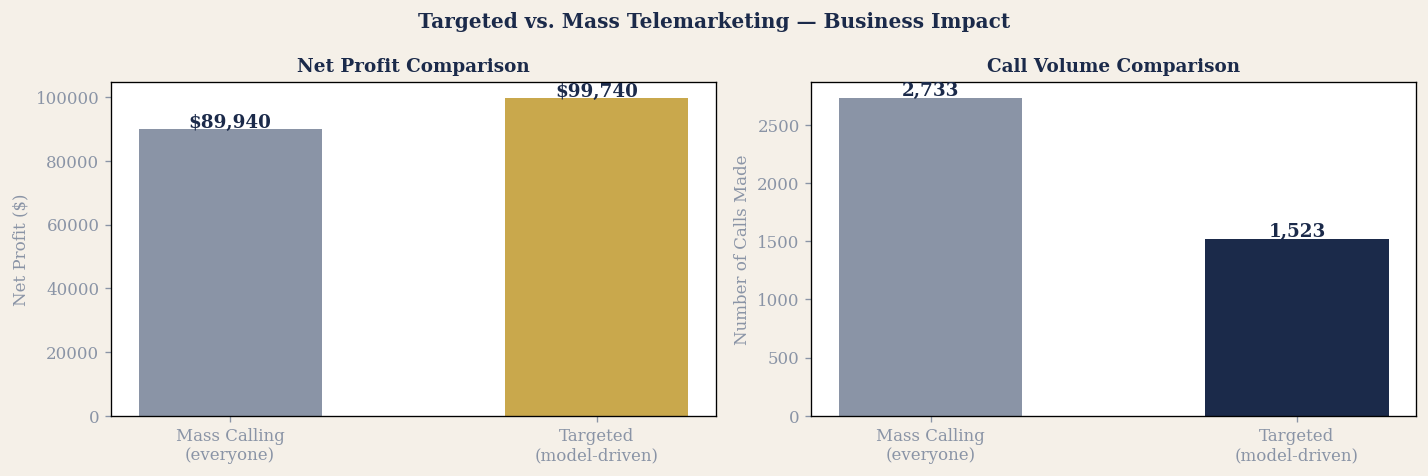

In [14]:
# ── Profit comparison chart ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor(CREAM)

# Profit comparison
ax = axes[0]
ax.set_facecolor('white')
strategies = ['Mass Calling\n(everyone)', 'Targeted\n(model-driven)']
profits    = [profit_all, profit_targeted]
bars = ax.bar(strategies, profits, color=[MUTED, GOLD], width=0.5)
ax.set_title('Net Profit Comparison', fontsize=11, fontweight='bold', color=NAVY)
ax.set_ylabel('Net Profit ($)', color=MUTED)
ax.tick_params(colors=MUTED)
for bar, val in zip(bars, profits):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'${val:,.0f}', ha='center', fontweight='bold', color=NAVY, fontsize=11)

# Call volume comparison
ax2 = axes[1]
ax2.set_facecolor('white')
calls   = [n_test,      n_targeted]
bars2 = ax2.bar(strategies, calls, color=[MUTED, NAVY], width=0.5)
ax2.set_title('Call Volume Comparison', fontsize=11, fontweight='bold', color=NAVY)
ax2.set_ylabel('Number of Calls Made', color=MUTED)
ax2.tick_params(colors=MUTED)
for bar, val in zip(bars2, calls):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{val:,}', ha='center', fontweight='bold', color=NAVY, fontsize=11)

plt.suptitle('Targeted vs. Mass Telemarketing — Business Impact',
             fontsize=12, fontweight='bold', color=NAVY)
plt.tight_layout()
plt.show()

---
## 11. Summary of Results

| Metric | Mass Calling | Targeted Calling | Change |
|---|---|---|---|
| Customers called | 2,733 | 1,523 | −44% |
| Subscribers reached | 723 | 651 | −10% |
| Net profit | $89,940 | $99,740 | **+$9,800 (+11%)** |
| Sensitivity (Recall) | — | 90.0% | — |
| Specificity | — | 56.6% | — |
| Precision | — | ~42.7% | — |
| AUC | — | ~0.78 | — |

**Key takeaway:** The model correctly identifies 90% of actual subscribers while cutting call volume by 44%. The trade-off — missing ~10% of subscribers — is more than compensated by the cost savings from not calling 1,210 low-probability customers. Less activity, smarter allocation, better outcome.

**Why sensitivity is intentionally high:** The 10% cutoff is deliberately low because the revenue/cost ratio (200/20 = 10×) means missing a subscriber is far more expensive than making an unnecessary call. The model is tuned to the economics, not to an arbitrary 50% threshold.